# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.


---

**MLOps Assignment: Predictive Maintenance Classification**

**Name:** Neeraj N

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('train.csv')
current = pd.read_csv('current.csv')
stress  = pd.read_csv('stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# Data quality check: confirms no imputation or de-duplication needed
print('\n--- Data quality check (train) ---')
train.info()
print('\nMissing values per column:')
print(train.isnull().sum())
print('\nDuplicate rows:', train.duplicated().sum())

# TODO: Display first 5 rows of train
train.head()

train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)

--- Data quality check (train) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6993 entries, 0 to 6992
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 6993 non-null   object 
 1   Air temperature      6993 non-null   float64
 2   Process temperature  6993 non-null   float64
 3   Rotational speed     6993 non-null   int64  
 4   Torque               6993 non-null   float64
 5   Tool wear            6993 non-null   int64  
 6   Failure_Type         6993 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 382.6+ KB

Missing values per column:
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Failure_Type           0
dtype: int64

Duplicate rows: 0


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [3]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
# Ranges are physical operating limits, not observed min/max
schema = DataFrameSchema({
    'Type':                Column(str,   Check.isin(['L', 'M', 'H'])),
    'Air temperature':     Column(float, Check.in_range(295.0, 305.0)),
    'Process temperature': Column(float, Check.in_range(305.0, 315.0)),
    'Rotational speed':    Column(int,   Check.in_range(1000, 2900)),
    'Torque':              Column(float, Check.in_range(3.0, 80.0)),
    'Tool wear':           Column(int,   Check.in_range(0, 253)),
    'Failure_Type':        Column(int,   Check.isin([0, 1, 2, 3, 4])),
})

# Dtypes fixed before validation: Pandera rejects int columns typed as float
def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
print('train   : schema validation PASSED')

schema.validate(current)
print('current : schema validation PASSED')

# TODO: Validate stress with lazy=True and print violation summary
# lazy=True colects all violations instead of stopping at the first
try:
    schema.validate(stress, lazy=True)
    print('stress  : schema validation PASSED - 0 violations')
except pa.errors.SchemaErrors as err:
    print(f'stress  : schema validation FAILED - {len(err.failure_cases)} violations')
    print(err.failure_cases.groupby(['column', 'check']).size())

print('\nNote: valid does not mean stable. stress.csv satisfies every schema '
      'constraint but may still be distributionally shifted. Pandera checks '
      'validity; Evidently (Section 3) checks distribution.')

train   : schema validation PASSED
current : schema validation PASSED
stress  : schema validation PASSED - 0 violations

Note: valid does not mean stable. stress.csv satisfies every schema constraint but may still be distributionally shifted. Pandera checks validity; Evidently (Section 3) checks distribution.


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Class distribution of Failure_Type:
                count  percent
0 - No Failure   6762    96.70
1 - TWF            30     0.43
2 - HDF            76     1.09
3 - PWF            56     0.80
4 - OSF            69     0.99

Imbalance ratio (majority:rarest) = 225 : 1

Type (machine quality) distribution:
      count  percent
Type                
L      4213    60.25
M      2074    29.66
H       706    10.10


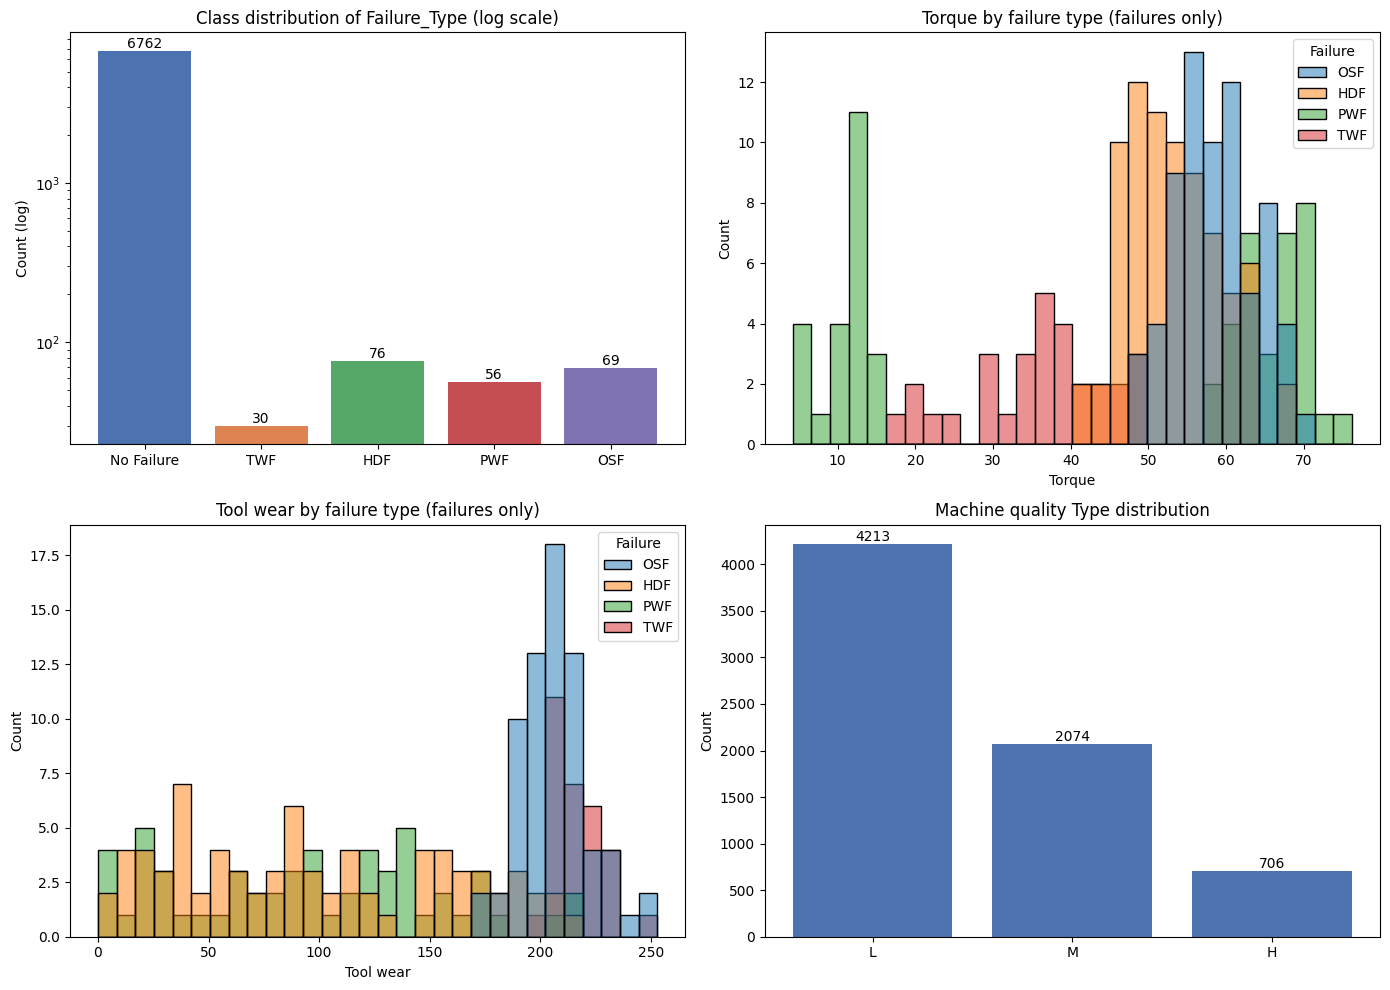

In [4]:
# TODO: Class distribution (print + bar chart)
counts = train['Failure_Type'].value_counts().sort_index()
pct = (counts / len(train) * 100).round(2)
dist = pd.DataFrame({'count': counts, 'percent': pct})
dist.index = [f'{i} - {CLASS_NAMES[i]}' for i in dist.index]
print('Class distribution of Failure_Type:')
print(dist)
print(f'\nImbalance ratio (majority:rarest) = {counts.max() / counts.min():.0f} : 1')

# TODO: Type distribution
print('\nType (machine quality) distribution:')
type_counts = train['Type'].value_counts()
print(pd.DataFrame({'count': type_counts,
                    'percent': (type_counts / len(train) * 100).round(2)}))

failures = train[train['Failure_Type'] != 0].copy()
failures['Failure'] = failures['Failure_Type'].map(CLASS_NAMES)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Log scale: linear would flaten all four failure classes against 6762
ax = axes[0, 0]
bars = ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values,
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3'])
ax.set_yscale('log')
ax.set_title('Class distribution of Failure_Type (log scale)')
ax.set_ylabel('Count (log)')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha='center', va='bottom')

# TODO: Torque distribution by failure type (histogram, failures only)
ax = axes[0, 1]
sns.histplot(data=failures, x='Torque', hue='Failure', bins=30, multiple='layer', ax=ax)
ax.set_title('Torque by failure type (failures only)')

# TODO: Tool wear distribution by failure type
ax = axes[1, 0]
sns.histplot(data=failures, x='Tool wear', hue='Failure', bins=30, multiple='layer', ax=ax)
ax.set_title('Tool wear by failure type (failures only)')

ax = axes[1, 1]
order = ['L', 'M', 'H']
bars = ax.bar(order, [type_counts.get(t, 0) for t in order], color='#4C72B0')
ax.set_title('Machine quality Type distribution')
ax.set_ylabel('Count')
for b, t in zip(bars, order):
    ax.text(b.get_x() + b.get_width() / 2, type_counts.get(t, 0),
            str(type_counts.get(t, 0)), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')  # before show()
plt.show()

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [5]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W']   = df['Torque'] * (df['Rotational speed'] * 2 * np.pi / 60)
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

# Applied to all three datasets, not just train
train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
grouped = train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean().round(2)
grouped.index = [f'{i} - {CLASS_NAMES[i]}' for i in grouped.index]
print('Mean engineered features by Failure_Type:')
print(grouped)

print('\nEngineered features applied to all three datasets:')
for name, df in [('train', train), ('current', current), ('stress', stress)]:
    print(f'  {name:8s}: {list(df.columns[-2:])}  shape={df.shape}')

Mean engineered features by Failure_Type:
                Power_W  Temp_diff
0 - No Failure  6248.24      10.01
1 - TWF         5763.09       9.97
2 - HDF         7403.55       8.23
3 - PWF         6664.38       9.82
4 - OSF         8216.07      10.07

Engineered features applied to all three datasets:
  train   : ['Power_W', 'Temp_diff']  shape=(6993, 9)
  current : ['Power_W', 'Temp_diff']  shape=(1499, 9)
  stress  : ['Power_W', 'Temp_diff']  shape=(1499, 9)


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib

# TODO: Encode Type column
# Fit on train only, transform the rest, to keep the maping consistent
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

joblib.dump(le, 'label_encoder.pkl')
print('Saved label_encoder.pkl  | mapping:',
      dict(zip(le.classes_, le.transform(le.classes_))))

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
# stratify=y matters: TWF has only 30 rows in total
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'\nX_train: {X_train.shape}   X_val: {X_val.shape}')

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
# After the split and on the training split only, to avoid leakage mainly
smote = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
# Validation left at natural imbalance, which is what production looks like
before = y_train.value_counts().sort_index()
after  = pd.Series(y_res).value_counts().sort_index()
comparison = pd.DataFrame({
    'train split (before SMOTE)': before,
    'train split (after SMOTE)':  after,
    'val split (untouched)':      y_val.value_counts().sort_index(),
})
comparison.index = [f'{i} - {CLASS_NAMES[i]}' for i in comparison.index]
print('\nClass distribution:')
print(comparison)
print(f'\nRows before SMOTE: {len(y_train)}  ->  after SMOTE: {len(y_res)}')
print(f'Validation set left at natural imbalance: {len(y_val)} rows')

Saved label_encoder.pkl  | mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

X_train: (5594, 8)   X_val: (1399, 8)

Class distribution:
                train split (before SMOTE)  train split (after SMOTE)  \
0 - No Failure                        5409                       5409   
1 - TWF                                 24                       5409   
2 - HDF                                 61                       5409   
3 - PWF                                 45                       5409   
4 - OSF                                 55                       5409   

                val split (untouched)  
0 - No Failure                   1353  
1 - TWF                             6  
2 - HDF                            15  
3 - PWF                            11  
4 - OSF                            14  

Rows before SMOTE: 5594  ->  after SMOTE: 27045
Validation set left at natural imbalance: 1399 rows


*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE builds synthetic minority samples by interpolating between real neighbours, so if I ran it before the split, synthetic rows derived from validation samples would end up in training. The model would then be scored on data it had effectively already seen and every metric would come out inflated.

I left the validation set at its natural 96.7% / 0.43% imbalance on purpose, because that is the distribution the deployed model actually faces. Rebalancing it would make the validation scores optimistic and useless for deciding what to ship.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [8]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#    Start an MLflow run
#    Fit on X_res, y_res
#    Predict on X_val
#    Compute and log macro_f1, weighted_f1, accuracy, perclas F1
#    Log the model artefact (use input_example=X_val.iloc[:5])
for name, model in models_to_run.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_res, y_res)
        y_pred = model.predict(X_val)

        # macro_f1 weights all 5 classes equaly; accuracy is secondary here
        macro_f1    = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')
        accuracy    = accuracy_score(y_val, y_pred)
        per_class   = f1_score(y_val, y_pred, average=None, labels=CLASS_LIST)

        mlflow.log_param('model', name)
        mlflow.log_param('smote_k_neighbors', 3)
        mlflow.log_param('train_rows_after_smote', len(y_res))

        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy', accuracy)
        for c in CLASS_LIST:
            mlflow.log_metric(f'f1_class_{c}_{CLASS_NAMES[c].replace(" ", "_")}',
                              per_class[c])

        mlflow.sklearn.log_model(model, 'model', input_example=X_val.iloc[:5])

        results[name] = {
            'macro_f1': macro_f1, 'weighted_f1': weighted_f1, 'accuracy': accuracy,
            **{CLASS_NAMES[c]: per_class[c] for c in CLASS_LIST},
        }
        print(f'{name:20s} macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}  acc={accuracy:.4f}')

# TODO: Print comparison table
comparison = pd.DataFrame(results).T.round(4).sort_values('macro_f1', ascending=False)
print('\n=== Model comparison (sorted by macro F1) ===')
print(comparison.to_string())

# TODO: Identify best model by macro F1
# Both winners printed: they disagre
best_model_name = comparison.index[0]
print(f'\nBest model by macro F1: {best_model_name} '
      f'(macro_f1 = {comparison.loc[best_model_name, "macro_f1"]:.4f})')
print(f'Best model by accuracy : {comparison["accuracy"].idxmax()} '
      f'(accuracy = {comparison["accuracy"].max():.4f})')

runs = mlflow.search_runs(experiment_names=['PredMaint_ModelSelection'])
print(f'\nMLflow runs logged: {len(runs)}')
print(runs[['tags.mlflow.runName', 'params.model',
            'metrics.macro_f1', 'metrics.accuracy']].to_string(index=False))

LogisticRegression   macro_f1=0.5312  weighted_f1=0.9328  acc=0.9042
RandomForest         macro_f1=0.7355  weighted_f1=0.9855  acc=0.9850
XGBoost              macro_f1=0.7481  weighted_f1=0.9851  acc=0.9843
LightGBM             macro_f1=0.7296  weighted_f1=0.9851  acc=0.9843

=== Model comparison (sorted by macro F1) ===
                    macro_f1  weighted_f1  accuracy  No Failure     TWF     HDF     PWF     OSF
XGBoost               0.7481       0.9851    0.9843      0.9922  0.1333  0.9655  0.8800  0.7692
RandomForest          0.7355       0.9855    0.9850      0.9926  0.0000  0.9286  0.9565  0.8000
LightGBM              0.7296       0.9851    0.9843      0.9922  0.0000  0.9655  0.8333  0.8571
LogisticRegression    0.5312       0.9328    0.9042      0.9483  0.1449  0.4545  0.4583  0.6500

Best model by macro F1: XGBoost (macro_f1 = 0.7481)
Best model by accuracy : RandomForest (accuracy = 0.9850)

MLflow runs logged: 6
tags.mlflow.runName       params.model  metrics.macro_f1  metri

### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [9]:
import optuna
import joblib
from mlflow.tracking import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)
    model.fit(X_res, y_res)
    return f1_score(y_val, model.predict(X_val), average='macro')

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f'Best trial value (macro F1): {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

# TODO: Train final best model
best_params = {**study.best_params,
               'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0}
best_model = XGBClassifier(**best_params)
best_model.fit(X_res, y_res)
y_pred = best_model.predict(X_val)

tuned_macro_f1 = f1_score(y_val, y_pred, average='macro')
tuned_weighted = f1_score(y_val, y_pred, average='weighted')
tuned_accuracy = accuracy_score(y_val, y_pred)
per_class      = f1_score(y_val, y_pred, average=None, labels=CLASS_LIST)

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
with mlflow.start_run(run_name='XGBoost_Optuna_Best'):
    mlflow.log_param('model', 'XGBoost_Optuna')
    mlflow.log_param('n_trials', 30)
    mlflow.log_params(study.best_params)
    mlflow.log_metric('macro_f1', tuned_macro_f1)
    mlflow.log_metric('weighted_f1', tuned_weighted)
    mlflow.log_metric('accuracy', tuned_accuracy)
    for c in CLASS_LIST:
        mlflow.log_metric(f'f1_class_{c}_{CLASS_NAMES[c].replace(" ", "_")}', per_class[c])
    mlflow.sklearn.log_model(best_model, 'model',
                             input_example=X_val.iloc[:5],
                             registered_model_name='PredMaint_XGBoost')

# MLflow 2.x uses aliases instead of stage transitions!
client = MlflowClient()
versions = client.search_model_versions("name='PredMaint_XGBoost'")
latest = max(int(v.version) for v in versions)
client.set_registered_model_alias('PredMaint_XGBoost', 'production', latest)
print(f'\nRegistered PredMaint_XGBoost version {latest}, alias -> production')

alias_mv = client.get_model_version_by_alias('PredMaint_XGBoost', 'production')
print(f'Verified alias: version {alias_mv.version}, run_id {alias_mv.run_id}')

# TODO: Save with joblib.dump
joblib.dump(best_model, 'best_model.pkl')
print('Saved best_model.pkl')

baseline_macro_f1 = results['XGBoost']['macro_f1']
delta = tuned_macro_f1 - baseline_macro_f1
print(f'\nBaseline XGBoost macro F1 : {baseline_macro_f1:.4f}')
print(f'Optuna-tuned  macro F1    : {tuned_macro_f1:.4f}')
print(f'Improvement               : {delta:+.4f} ({delta / baseline_macro_f1 * 100:+.2f}%)')

print('\nPer-class F1 of tuned model:')
for c in CLASS_LIST:
    print(f'  {CLASS_NAMES[c]:12s}: {per_class[c]:.4f}')

2026/08/04 11:38:22 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_Optuna' does not exist. Creating a new experiment.


Best trial value (macro F1): 0.7672
Best params:
  n_estimators: 407
  max_depth: 6
  learning_rate: 0.032501348640434566
  min_child_weight: 4.9431715074202085
  subsample: 0.8363548736010727
  colsample_bytree: 0.9147422831957723
  gamma: 1.6298148775915886
  reg_alpha: 3.5960813125765804e-05
  reg_lambda: 0.009187218047421591

Registered PredMaint_XGBoost version 1, alias -> production
Verified alias: version 1, run_id 61b16dc9a06f44839e497777a0e1bebc
Saved best_model.pkl

Baseline XGBoost macro F1 : 0.7481
Optuna-tuned  macro F1    : 0.7672
Improvement               : +0.0192 (+2.56%)

Per-class F1 of tuned model:
  No Failure  : 0.9885
  TWF         : 0.0690
  HDF         : 0.9655
  PWF         : 0.9167
  OSF         : 0.8966


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [10]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# Let's do simple statistics first, before trusting any drift tool
quick = pd.DataFrame({
    'train (reference)': train[FEAT_COLS].mean(),
    'current':           current[FEAT_COLS].mean(),
    'stress':            stress[FEAT_COLS].mean(),
}).round(2)
quick['current - train'] = (quick['current'] - quick['train (reference)']).round(2)
quick['stress - train']  = (quick['stress']  - quick['train (reference)']).round(2)
print('Quick statistical comparison before running Evidently:')
print(quick.to_string())

# TODO: Run Evidently on current batch, save drift_current.html, print summary
report_current = Report(metrics=[DataDriftPreset()])
report_current.run(reference_data=train[FEAT_COLS], current_data=current[FEAT_COLS])
report_current.save_html('drift_current.html')

res = report_current.as_dict()['metrics'][0]['result']
print('\n=== Evidently: CURRENT batch (reference = train) ===')
print(f'Dataset drift detected : {res["dataset_drift"]}')
print(f'Columns analysed       : {res["number_of_columns"]}')
print(f'Columns drifted        : {res["number_of_drifted_columns"]}')
print(f'Share drifted          : {res["share_of_drifted_columns"]:.2f} '
      f'(threshold {res["drift_share"]})')
print('Saved drift_current.html')

Quick statistical comparison before running Evidently:
                     train (reference)  current   stress  current - train  stress - train
Air temperature                 300.01   299.92   300.05            -0.09            0.04
Process temperature             310.00   310.00   310.01             0.00            0.01
Rotational speed               1539.02  1530.17  1497.07            -8.85          -41.95
Torque                           40.00    40.22    44.72             0.22            4.72
Tool wear                       107.68   108.20   148.87             0.52           41.19

=== Evidently: CURRENT batch (reference = train) ===
Dataset drift detected : False
Columns analysed       : 5
Columns drifted        : 0
Share drifted          : 0.00 (threshold 0.5)
Saved drift_current.html


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [11]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
metrics = [DatasetDriftMetric()] + [
    ColumnDriftMetric(column_name=c, stattest='wasserstein') for c in FEAT_COLS
]
report_stress = Report(metrics=metrics)
report_stress.run(reference_data=train[FEAT_COLS], current_data=stress[FEAT_COLS])

# TODO: Save drift_stress.html
report_stress.save_html('drift_stress.html')

d = report_stress.as_dict()
ds = d['metrics'][0]['result']
print('=== Evidently: STRESS batch (reference = train) ===')
print(f'Dataset drift detected : {ds["dataset_drift"]}')
print(f'Columns drifted        : {ds["number_of_drifted_columns"]} of {ds["number_of_columns"]}')
print('Saved drift_stress.html')

# TODO: Print per-column drift table
rows = []
for m in d['metrics'][1:]:
    r = m['result']
    col = r['column_name']
    ref_mean = train[col].mean()
    cur_mean = stress[col].mean()
    rows.append({
        'feature':     col,
        'drift?':      'YES' if r['drift_detected'] else 'no',
        'wasserstein': round(r['drift_score'], 4),
        'ref mean':    round(ref_mean, 2),
        'stress mean': round(cur_mean, 2),
        'delta':       round(cur_mean - ref_mean, 2),
        'delta %':     round((cur_mean - ref_mean) / ref_mean * 100, 2),
    })

drift_table = pd.DataFrame(rows).sort_values('wasserstein', ascending=False)
print('\nPer-feature drift (stattest = Wasserstein, threshold 0.1):')
print(drift_table.to_string(index=False))

drifted = drift_table.loc[drift_table['drift?'] == 'YES', 'feature'].tolist()
print(f'\nDrifted features: {drifted}')

=== Evidently: STRESS batch (reference = train) ===
Dataset drift detected : True
Columns drifted        : 3 of 5
Saved drift_stress.html

Per-feature drift (stattest = Wasserstein, threshold 0.1):
            feature drift?  wasserstein  ref mean  stress mean  delta  delta %
          Tool wear    YES       0.6455    107.68       148.87  41.19    38.25
             Torque    YES       0.4739     40.00        44.72   4.73    11.82
   Rotational speed    YES       0.2354   1539.02      1497.07 -41.94    -2.73
Process temperature     no       0.0377    310.00       310.01   0.00     0.00
    Air temperature     no       0.0344    300.01       300.05   0.04     0.01

Drifted features: ['Tool wear', 'Torque', 'Rotational speed']


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

**1. Features that drifted:**

Three of the five features drifted in the stress batch. The curent batch drifted on none of them, which is what makes this result trustworthy rather than an artefact of my setup.

Ranked by Wasserstein distance against a threshold of 0.1: tool wear 0.6455 (mean 107.68 to 148.87, up 38.25%), torque 0.4739 (40.00 to 44.72, up 11.82%), and rotational speed 0.2354 (1539.02 to 1497.07, down 2.73%). Air temperature (0.0344) and process temperature (0.0377) did not move.

Worth stating plainly: `stress.csv` passed Pandera validation with zero violations. Every value sits inside its legal range. Schema checking would have waved this batch straight through, and only distrbution monitoring caught it.

**2. Most likely failure type to increase:**

OSF, overstrain failure.

The SHAP results in Section 4.1 show OSF is driven by torque (mean |SHAP| 1.9023) and tool wear (1.8693) at almost identical weight. Those are exactly the two features that drifted hardest, and both moved upward. On top of that the stress batch shows lower rotational sped alongside the higher torque, which is the overstrain regime in physical terms: a worn tool being forced through material at high load and low speed.

HDF is not at elevated risk, and I can say that from the same evidence. Its dominant driver is Temp_diff at 2.6996, and neither temperature column drifted at all.

**3. Retraining recommendation:**

Yes, retrain.

The chain is short enough to state in one sentence: the two features carrying the most SHAP weight for OSF have both drifted well past threshold, the batch is schema-valid so nothing in the data quality layer would alert, and the model was fitted on data averaging 107.68 minutes of tool wear while it is now scoring data averaging 148.87.

The model is not broken. It is stale, and it is stale specifically in the region of feature space that decides OSF.

Two things I would change alongside the retrain. Include stress-period data in the training set so the heavy-load regime is actually represented rather than extrapolated. And set the drift alerts on tool wear and torque individually, because agregate dataset drift needs half the columns to move before it fires, which here would have meant waiting for a third feature to go.

## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

SHAP array shape (samples, features, classes): (6993, 8, 5)


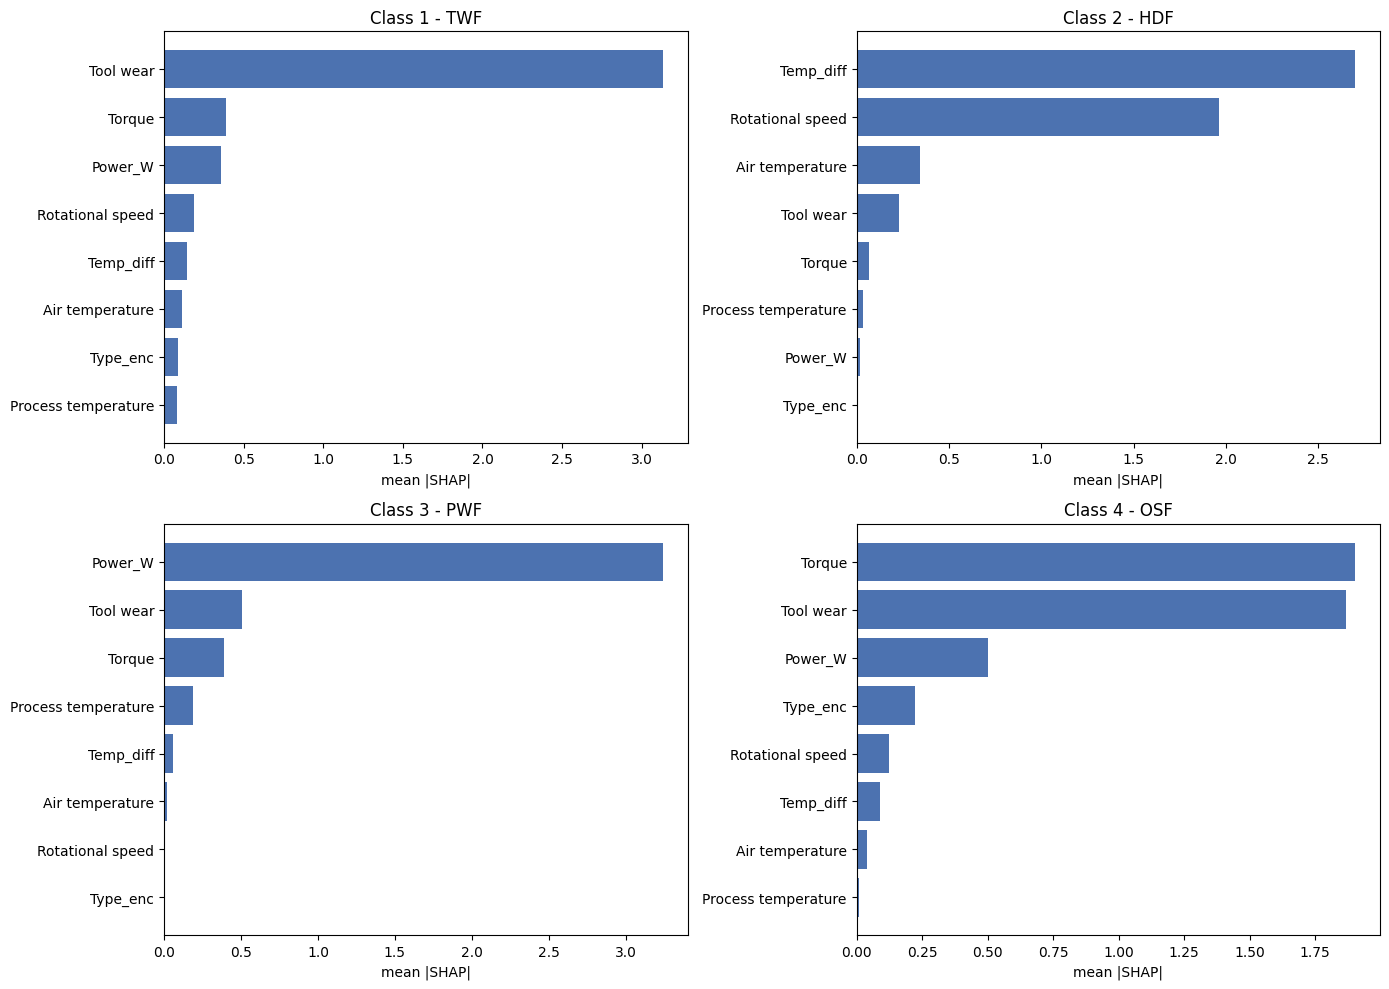


Top driver per failure class:
  TWF  : Tool wear            (mean |SHAP| = 3.1313)
  HDF  : Temp_diff            (mean |SHAP| = 2.6996)
  PWF  : Power_W              (mean |SHAP| = 3.2392)
  OSF  : Torque               (mean |SHAP| = 1.9023)

Full mean |SHAP| ranking per class:
                        TWF     HDF     PWF     OSF
Type_enc             0.0896  0.0076  0.0000  0.2245
Air temperature      0.1098  0.3421  0.0183  0.0380
Process temperature  0.0822  0.0355  0.1879  0.0074
Rotational speed     0.1850  1.9648  0.0067  0.1248
Torque               0.3907  0.0645  0.3896  1.9023
Tool wear            3.1313  0.2298  0.5086  1.8693
Power_W              0.3599  0.0159  3.2392  0.5031
Temp_diff            0.1411  2.6996  0.0555  0.0888


In [12]:
import shap

best_model = joblib.load('best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
explainer   = shap.TreeExplainer(best_model)
shap_values = np.array(explainer.shap_values(train[FEATURES]))
print('SHAP array shape (samples, features, classes):', shap_values.shape)

# TODO: Plot 4-subplot bar chart (one per failure class)
# Read per class, never colapsed into a single global ranking
FAILURE_CLASSES = [1, 2, 3, 4]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
top_drivers = {}

for ax, c in zip(axes.ravel(), FAILURE_CLASSES):
    mean_abs = np.abs(shap_values[:, :, c]).mean(axis=0)
    order = np.argsort(mean_abs)
    ax.barh([FEATURES[i] for i in order], mean_abs[order], color='#4C72B0')
    ax.set_title(f'Class {c} - {CLASS_NAMES[c]}')
    ax.set_xlabel('mean |SHAP|')
    top_drivers[CLASS_NAMES[c]] = (FEATURES[order[-1]], mean_abs[order[-1]])

plt.tight_layout()
# TODO: Save shap_per_class.png
plt.savefig('shap_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: Print top driver per class
print('\nTop driver per failure class:')
for cls, (feat, val) in top_drivers.items():
    print(f'  {cls:5s}: {feat:20s} (mean |SHAP| = {val:.4f})')

rank = pd.DataFrame(
    {CLASS_NAMES[c]: np.abs(shap_values[:, :, c]).mean(axis=0) for c in FAILURE_CLASSES},
    index=FEATURES).round(4)
print('\nFull mean |SHAP| ranking per class:')
print(rank.to_string())

### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

**1. Power_W for PWF:**

Power_W is the top driver for PWF at mean |SHAP| 3.2392. Raw torque scores 0.3896 and raw rotational speed scores 0.0067. So the derived feature is about 8 times more useful than torque and roughly 480 times more useful than speed.

The EDA plot in Section 1.3 explains why. PWF is bimodal in torque: the failures cluster at 5 to 15 Nm and again at 65 to 75 Nm, with almost nothing in betwen. No single threshold on torque separates that, because a cut anywhere in the middle catches neither group. Power is torque times angular velocity, so both tails collapse into one number the model can actually split on.

This is the clearest evidence in the whole notebook that a feature built from physics beats the raw sensor columns it came from.

**2. Temp_diff for HDF:**

Temp_diff is the top driver for HDF at 2.6996. For the other three classes it scores 0.1411 (TWF), 0.0555 (PWF) and 0.0888 (OSF), so it is somewhere between 19 and 49 times more important for HDF than anywhere else. It is close to a single-purpose feature.

Rotational speed is second for HDF at 1.9648, which fits: a narrow gap between process and ambient temperature means the machine is not sheding heat, and low spindle speed meansless airflow to shed it with. Both conditions have to be present.

**3. Physical mechanisms:**

TWF is almost entirely tool wear (3.1313, with everything else below 0.4). It is a time-in-service failure, the tool degrades with accumulated minutes whatever the load.

HDF needs two things together, a collapsed Temp_diff (2.6996) and low rotational speed (1.9648). The machine is producing heat it cannot get rid of.

PWF is Power_W on its own (3.2392) and fails at both ends of the power envelope, either too little power to finish the cut or too much for the drivetrain to take.

OSF is torque (1.9023) and tool wear (1.8693) at nearly equal weight, which is the overstain product: a worn tool being pushed hard.

**Actionable recommendation:**

- **Condition:** tool wear above roughly 200 minutes at the same time as torque above roughly 50 Nm.
- **Risked failure class:** OSF (Overstrain Failure).
- **Action:** replace tools at 200 minutes rather than runing to the 253 minute limit, and cap sustained torque during heavy-load runs. Start with the L-grade machines, which are 60.25% of the fleet.

## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**

XGBoost won with a macro F1 of 0.7481. Random Forest came close at 0.7355, LightGBM at 0.7296, and Logistic Regression was well behind at 0.5312. I then tuned XGBoost with 30 Optuna trials and got it up to 0.7672, a gain of 2.56% over its own baseline.

I compared on macro F1 rather than accuracy because it treats all five clases equally, so a model only scores well if it can actually pick out the four rare failure modes. Logistic Regression shows why the tree models win: it managed only 0.4545 on HDF and 0.4583 on PWF, about half what XGBoost got. The relationship between torque, speed and wear is not linear, and a linear model cannot represent it.

**2. Accuracy vs Macro F1:**

Class 0 is 96.7% of the data. So a model that predicts "No Failure" every single time scores 96.7% accuracy and catches nothing. That is not a hypothetical here, it actually hapened in my results. Random Forest had the best accuracy of any model at 0.9850, but its TWF F1 was 0.0000. It never predicted a tool wear failure once. XGBoost was slightly worse on accuracy at 0.9843 but better on macro F1 at 0.7481.

If I had selected on accuracy I would have shipped the model that is completely blind to one of the failure modes. Weighted F1 has the same blind spot, since all four models sit above 0.93 on it no matter how badly they do on the rare classes.

The cost side is lopsided. A false positive means one inspection that turned out to be unnecesary. A false negative means the line stops, at 8 to 15 lakh rupees an hour. Those are not remotely the same mistake, and accuracy treats them as if they were.

**3. The TWF problem:**

This is a data problem, not a modelling problem. There are 30 TWF rows in the whole dataset, which is 0.43% of 6993. After the split only 24 are left to train on and 6 to validate against. With 6 validation samples, one prediction changes TWF F1 by about 0.17, so the metric is barely stable enough to mean anything.

SMOTE took those 24 rows up to 5409 synthetic ones, but interpolating between 24 points does not create new information. It just resamples the same small corner of the feature space over and over.

Tuning actually made TWF worse, not better. It went from 0.1333 down to 0.0690 while macro F1 went up. Optuna was right to do that: it gained 0.13 on OSF and 0.04 on PWF by giving up on a class it could not learn, and that raises the average. Which is the point. No amount of resampling or hyperparameter search fixes missing data.

What would actually fix it is collecting more TWF examples. I would instrument tool-change events to capture the run-up to these failures and target something like 300 to 500 labeled cases. Until then it would be more honest to pull TWF out into its own binary anomaly detector with a threshold tuned for recall, rather than pretending the five-class model handles it.

**4. Drift and maintenance schedule:**

The current batch came back completely clean, zero drifted features. That matters, because it means the drift I found in the stress batch is real and not just noise in my setup.

The stress batch drifted on three of five features. Tool wear moved most (Wasserstein 0.6455, mean up from 107.68 to 148.87, +38.25%), then torque (0.4739, 40.00 to 44.72, +11.82%), then rotational speed (0.2354, 1539.02 to 1497.07, -2.73%). Both temperature columns did not move at all.

For maintenance scheduling this is fairly blunt: under heavy load the machines are picking up 38% more tool wear than the training data assumed. Any replacement interval set from baseline data is now too long. Servicing needs to key off measured wear instead of a fixed clock.

The part I found most interesting is that `stress.csv` passed Pandera with zero violations. Nothing in the data quality layer would have raised a flag. The data was completely legal and completely wrong for the model, and only distribution monitoring picked it up.

**5. Actionable recommendation:**

- **Condition:** tool wear above roughly 200 minutes at the same time as torque above roughly 50 Nm.
- **Risked failure class:** OSF (Overstrain Failure).
- **Action:** replace tools at 200 minutes instead of running them to the 253 minute limit, and cap sustained torque during heavy-load runs.

SHAP puts OSF down to torque (mean |SHAP| 1.9023) and tool wear (1.8693), almost equally weighted. Those are the same two features that drifted hardest in the stress batch, and both moved upward. That is the whole argument for retraining in one line. I would retrain with stress-period data included so the heavy-load regime is actualy represented, and I would set drift alerts on tool wear and torque individually rather than on the aggregate, which trips later than it should.

### Assumptions made

1. I treated the Pandera ranges as the physical limits of the equipment, not as the min and max I happened to observe. A reading outside them is a sensor fault, not a rare valid state.
2. I treated `stress.csv` as valid but drifted, not as corrupt. It passed schema validation with zero violations, so that seemed like the right reading.
3. No mising values, no duplicates and no out-of-range readings in any of the three files, so I did no imputation, de-duplication or outlier removal.
4. I left the validation split at its natural imbalance on purpose, since that is what production looks like.
5. I fixed macro F1 as the selection metric before training anything, so the choice could not drift toward whatever scored best on accuracy.
6. The 200 minute and 50 Nm thresholds come off my own Section 1.3 plots, where OSF and TWF cluster. They would need checking against real maintenance records before anyone enforced them.


Easily the most fun assignment in the course so far. The moment that stuck was watching `stress.csv` sail through every schema check and still be quietly wrong for the model, which is not a failure mode I would have known to look for a week ago.